In [ ]:
import os
import torch
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/dataset'

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [ ]:
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
print("Classes:", full_dataset.classes)

Classes: ['green', 'red', 'yellow']


In [ ]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")

Train size: 1084 | Val size: 272


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)
print("Batch labels:", labels[:10])

Batch images shape: torch.Size([32, 3, 64, 64])
Batch labels: tensor([0, 2, 1, 1, 0, 2, 0, 1, 2, 1])


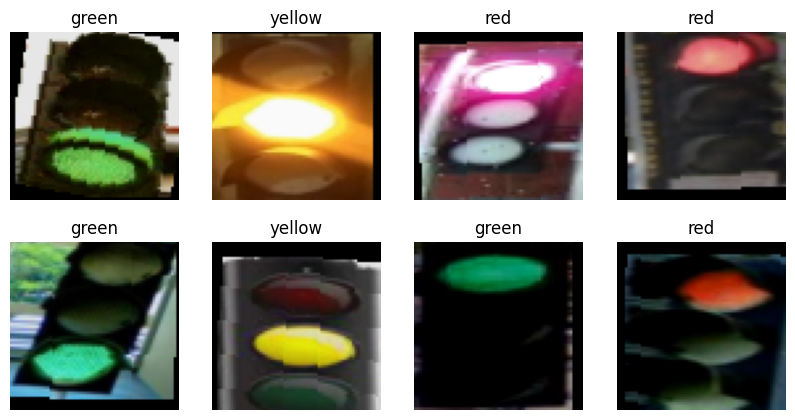

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 4, figsize=(10,5))
classes = full_dataset.classes

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0)  # translate from [C,H,W] to [H,W,C]
    img = (img * 0.5 + 0.5).numpy()   # denormalization
    label = labels[i].item()
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis('off')

plt.show()

# CNN model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
class TrafficLightCNN(nn.Module):
    def __init__(self):
        super(TrafficLightCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128 * 8 * 8, 256)   # after 3 poolings (64→32→16→8)
        self.fc2 = nn.Linear(256, 3)             # 3 classes
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 8 * 8)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TrafficLightCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Loss: {running_loss/len(train_loader):.4f} | "
          f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

Epoch [1/10] | Loss: 0.4493 | Train Acc: 85.52% | Val Acc: 97.79%
Epoch [2/10] | Loss: 0.1169 | Train Acc: 96.49% | Val Acc: 98.90%
Epoch [3/10] | Loss: 0.0961 | Train Acc: 98.25% | Val Acc: 97.79%
Epoch [4/10] | Loss: 0.0606 | Train Acc: 98.15% | Val Acc: 100.00%
Epoch [5/10] | Loss: 0.0523 | Train Acc: 98.71% | Val Acc: 99.26%
Epoch [6/10] | Loss: 0.0590 | Train Acc: 98.43% | Val Acc: 98.53%
Epoch [7/10] | Loss: 0.0363 | Train Acc: 99.08% | Val Acc: 98.53%
Epoch [8/10] | Loss: 0.0668 | Train Acc: 98.15% | Val Acc: 98.90%
Epoch [9/10] | Loss: 0.0423 | Train Acc: 98.89% | Val Acc: 99.63%
Epoch [10/10] | Loss: 0.0557 | Train Acc: 98.62% | Val Acc: 98.90%


In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/dataset/traffic_light_cnn.pth')

In [ ]:
from google.colab import files

files.download('/content/drive/MyDrive/dataset/traffic_light_cnn.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from PIL import Image

classes = full_dataset.classes
model.eval()

img_path = '/content/tl_red1.jpg'
img = Image.open(img_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

img_t = transform(img).unsqueeze(0).to(device)
output = model(img_t)
_, pred = torch.max(output, 1)

print("Prediction:", classes[pred.item()])

Предсказание: green
